# An Introduction to PyTorch for Remote Sensing
## Mikael Brunila<br>Geographic Information Centre (McGill)
### March 2025

## Overview: Part 2

- **A: Model training** (15 min)
  - Deep Learning
  - Splits: Train, validate, test
  - Torch Lightning
  - Torch models and Remote Sensing: Known Challenges
      - TorchGeo
- **B: Case: Land Classification with TorchGeo** (30 min)
  - Classifying land patches from the EuroSAT dataset
  - Datasets and Datamodules
  - Models and tasks
  - Test set evaluation
- **C: Case: Predicting on new data** (15 min)
  - Loading Sentinel-2 data with PyStac (recap)
  - Predict and visualize
- **D: Hands on: Predicting on new data** (30+ min)
  - Pick a new area and replicate part C

# [Part 2A] Model training

## Deep Learning

Deep learning is the process of learning from data through the chaining of "weights" matrices and very simple "activation" functions. 

We start with random values in the matrices and try to predict a label in our data. This is the **forward pass**.

If we predict wrong, we use calculus to estimate which weights to correct and how according to some **loss function**. Passing this correction backwards in the **backpropagation** step.

<center>
<div>
<img src="img/neural_network_matrices.png" width="50%"
     caption="test"/>
    <figcaption>A neural net can be thought of as a *sequence* of matrices. Each matrix multiplication transforms the network somehow.</figcaption>
</div>
</center>

## Deep Learning in PyTorch

- If we implement a model from scratch, we would write the `forward()` and loss function.
- However, Torch handles the backprop for us
- Optimizers are picked from a range of choices, like `SGD()` and `Adam()`

## Data Splits

In order to learn from data like this, we usually split our dataset in three parts:
    
1. **Training set:** Used to update the model's parameters by minimizing the loss function during learning.
2. **Validation set:** Used during training to tune hyperparameters and monitor the model's performance to avoid overfitting.
3. **Test set:** A held-out dataset used only for evaluating the final performance of the trained model on unseen data.

## PyTorch Lightning

- A high-level framework that streamlines PyTorch code by abstracting the engineering and boilerplate parts. 
- Organizes code into modular components
- Higher level of abstraction than PyTorch:
    - Easier to use, but more blackboxed
- Highly supported in GeoTorch

## GeoSpatial Data and Torch

- Often very large rasters
- More bands than just the standard RGB
- Added spatial metadata like coordinates and projections
- Intersecting datasets at different resolutons, projections, etc.
- Specialized tasks outside of the ordinary scope of Computer Vision

![](img/geodataset.png)

## GeoTorch

- Developed to respond to these challenges
    - Unified dataset APIs supporting a variety of remote sensing data formats and sources.
- Geospatially-aware data augmentation and transformation pipelines.
- Specialized samplers that preserve spatial context during data loading.
- Pre-built models and high-level task abstractions integrated with PyTorch Lightning for streamlined training, evaluation, and deployment.
- Tools for managing coordinate reference systems and geospatial metadata.

# [Part 2B] Case: Land Classification with TorchGeo

In [1]:
import lightning.pytorch as pl
import math
import numpy as np
import os
import random
import tempfile
import torch

from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint
from lightning.pytorch.loggers import CSVLogger

from torchgeo.datamodules import EuroSATDataModule
from torchgeo.datasets import EuroSAT
from torchgeo.trainers import ClassificationTask

from tqdm import tqdm

## PyTorch: Datasets

- Classes that encapsulate a collection of data samples.
- They let you define how data is loaded, pre-processed, and accessed from disk or memory.
- TorchGeo comes with a number of [predefined datasets](https://torchgeo.readthedocs.io/en/stable/api/datasets.html)
    - Some of these are explicitly geospatial, others are not
    - Even non-geospatial datasets usually make it comparatively easy to use multi-band data

## The EuroSAT dataset

- We will be using the [`EuroSAT` dataset](https://torchgeo.readthedocs.io/en/latest/api/datasets.html#eurosat). 
- Based on a [peer-review study](https://arxiv.org/abs/1709.00029)
- It provides 64x64 pixel samples of Sentinel-2 data with 
- Rasters are 13-channel GeoTiffs
- There are 9 labels for different classes of land

![](img/eurosat_labels.png)

We define these labels here.

In [567]:
labels_alphabetic = {
    0: "Annual Crop",
    1: "Forest",
    2: "Herbaceous Vegetation",
    3: "Highway",
    4: "Industrial Buildings",
    5: "Pasture",
    6: "Permanent Crop",
    7: "Residential Buildings",
    8: "River",
    9: "Sea & Lake",
}

We don't have to worry about downloading the data, the dataset function does that for us when we set `download=True`.

In [2]:
dataset = EuroSAT(root="data/eurosat", download=True)

100%|████████████████████████████████████████████████| 2067725275/2067725275 [01:29<00:00, 23139614.81it/s]


100%|█████████████████████████████████████████████████████████| 313605/313605 [00:00<00:00, 1193103.37it/s]


100%|██████████████████████████████████████████████████████████| 104659/104659 [00:00<00:00, 735687.79it/s]


100%|█████████████████████████████████████████████████████████| 104163/104163 [00:00<00:00, 1137334.92it/s]


Let's take a look at the dataset. We have 16200 images and 13 bands.

In [553]:
dataset

In [554]:
len(EuroSAT.BAND_SETS['all'])

13

In [555]:
print(EuroSAT.BAND_SETS['all'])

('B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B09', 'B10', 'B11', 'B12', 'B8A')


In [556]:
print(EuroSAT.BAND_SETS['rgb'])

('B04', 'B03', 'B02')


## Lightning: DataModules

- Often we would access
- However, today we are using PyTorch Lightning which provides a wrapper around a lot of the Torch boilerplate.
- In Lightning, there are **DataModules**, higher-level abstractions that organize all the data-related code in one place
- More reproducible, as all data handling logic is standardized in one module.

## The EuroSATDataModule

- In addition to a dataset, there is a designated `EuroSATDataModule`
- It's "non-spatial", but accomodates for many bands

In [ ]:
datamodule = EuroSATDataModule(
    root = "data/eurosat", 
    batch_size = 64, 
    num_workers = 6, 
    bands = EuroSAT.BAND_SETS["all"]
)

## Models and tasks

- In `torch` we would use something like `nn.Module()` to define a model architecture
- In `torchgeo`, we can use ["tasks"](https://torchgeo.readthedocs.io/en/stable/api/trainers.html) to collate much of the model pipeline into one framework
    - Model Architecture (e.g. YOLO)
    - Loss Function (e.g. cross-entropy)
    - Evaluation Metrics (e.g. Accuracy, F1 score)
    - Hyperparameters like learning rate
- Tasks are available for various geospatial problems (classification, object detection, segmentation, etc.)

## The Classification Task

- For land use classification we use the [`ClassificationTask()`](https://torchgeo.readthedocs.io/en/stable/api/trainers.html#torchgeo.trainers.ClassificationTask)
- We use all the channels (i.e. bands) and all classes
- As our architecture we use an 18-layer [Residual neural network](https://en.wikipedia.org/wiki/Residual_neural_network) with pre-training (`weights=True`)
- We use a cross-entropy loss and a learning rate of `0.001`
- The `patience` refers to how many epochs we can train without improvement before stopping

In [557]:
in_channels = len(EuroSAT.BAND_SETS['all'])
num_classes = len(datamodule.train_dataset.classes)

In [453]:
task = ClassificationTask(
    model = "resnet18",
    weights = True,
    in_channels = in_channels,
    num_classes = num_classes,
    loss = "ce",
    lr = 0.001,
    patience = 5,
)

INFO:timm.models._builder:Loading pretrained weights from Hugging Face hub (timm/resnet18.a1_in1k)
INFO:timm.models._hub:[timm/resnet18.a1_in1k] Safe alternative available for 'pytorch_model.bin' (as 'model.safetensors'). Loading weights using safetensors.
INFO:timm.models._builder:Converted input conv conv1 pretrained weights from 3 to 13 channel(s)
INFO:timm.models._builder:Missing keys (fc.weight, fc.bias) discovered while loading pretrained weights. This is expected if model is being adapted.


## Callback: `ModelCheckpoint()`

- We can also set various "Callbacks".
- The [`ModelCheckpoint()`](https://lightning.ai/docs/pytorch/stable/api/lightning.pytorch.callbacks.ModelCheckpoint.html) checks the validation loss at each epoch and then saves the model if it's better than the previous epoch
- It also always keeps the last model with `save_last=True`

In [558]:
experiment_dir = os.path.join(tempfile.gettempdir(), "eurosat_results")

checkpoint_callback = ModelCheckpoint(
    monitor = "val_loss",
    dirpath = experiment_dir,
    save_top_k = 1,
    save_last = True
)

## Callback: `EarlyStopping()`

- Early stopping also monitors validation loss 
- With `min_delta=0.00` any decrease, no matter how tiny, is considered an improvement and the model can keep training
- With `patience = 3` Ttaining stops if there is no improvement in validation loss for 5 consecutive epochs.

In [ ]:
early_stopping_callback = EarlyStopping(
    monitor = "val_loss",
    min_delta = 0.00,
    patience = 3
)

## Model logs

- With the `CSVLogger()` we log the results from each epoch in a csv file 

In [5]:
csv_logger = CSVLogger(
    save_dir = experiment_dir,
    name = "logs"
)

## Model training: `pl.Trainer()`

- To train the model, we initialize the Ligthning `pl.Trainer()` module
- Here we define our callbacks, logger, and experiment directory
- We also set `min_epochs` (the least number of epochs to run) and `max_epochs` (the max number of epochjs to run
- If we have GPU-access, we initialize the trainer it with `accelerator = "gpu"` and `devices=[0]`

In [6]:
if torch.device("cuda").type == "cuda" and torch.cuda.is_available():
    trainer = pl.Trainer(
      callbacks = [
          checkpoint_callback, 
          early_stopping_callback
      ],
      logger = [csv_logger],
      default_root_dir = experiment_dir,
      min_epochs = 1,
      max_epochs = 10,
      accelerator = "gpu",
      devices = [0]
    )
else:
    trainer = pl.Trainer(
      callbacks = [
          checkpoint_callback, 
          early_stopping_callback
      ],
      logger = [csv_logger],
      default_root_dir = experiment_dir,
      min_epochs = 1,
      max_epochs = 10,
    )

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


## Model training: `fit()`

- With our `trainer`, `task`, and `datamodule` initialized, we have everything we need to `fit()` the model
- We save the model as a `state_dict()`

In [559]:
train=False

In [7]:
if train==True:
    trainer.fit(
        model = task, 
        datamodule = datamodule)
    torch.save(task.state_dict(), "land_classifier_state_dict.pt")

/usr/local/Caskroom/miniconda/base/envs/rs-torch/lib/python3.12/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:654: Checkpoint directory /private/var/folders/zz/3lhn60g1163cfzw5vrc_yrp00000gn/T/eurosat_results exists and is not empty.

  | Name          | Type             | Params | Mode 
-----------------------------------------------------------
0 | model         | ResNet           | 11.2 M | train
1 | criterion     | CrossEntropyLoss | 0      | train
2 | train_metrics | MetricCollection | 0      | train
3 | val_metrics   | MetricCollection | 0      | train
4 | test_metrics  | MetricCollection | 0      | train
-----------------------------------------------------------
11.2 M    Trainable params
0         Non-trainable params
11.2 M    Total params
44.852    Total estimated model params size (MB)
110       Modules in train mode
0         Modules in eval mode


Sanity Checking: |                                                                   | 0/? [00:00<?, ?it/s]

Training: |                                                                          | 0/? [00:00<?, ?it/s]

Validation: |                                                                        | 0/? [00:00<?, ?it/s]

Validation: |                                                                        | 0/? [00:00<?, ?it/s]

...

Validation: |                                                                        | 0/? [00:00<?, ?it/s]

Validation: |                                                                        | 0/? [00:00<?, ?it/s]

Validation: |                                                                        | 0/? [00:00<?, ?it/s]

Validation: |                                                                        | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=10` reached.


## Model evaluation

- After running our model, we can can take a look at the metrics for our training
- It's unusual that validation scores are higher than training scores
    - This detail would be worth revisiting if this was intended for production or publication

In [560]:
for k, v in trainer.callback_metrics.items():
    print(f"{k}:{np.round(v.item(), 2)}")

train_loss:0.21
train_AverageAccuracy:0.75
train_F1Score:0.88
train_JaccardIndex:0.75
train_OverallAccuracy:0.88
val_loss:0.12
val_AverageAccuracy:0.96
val_F1Score:0.96
val_JaccardIndex:0.93
val_OverallAccuracy:0.96


## Model evaluation

- **Loss:** Average error
- **Average Accuracy:** Ratio of correctly classified patches (per class)
- **F1-Score:** The harmonic mean of precision and recall 
    - Precision: The ratio of true positives to the sum of true positives and false *positives*.
    - Recall: The ratio of true positives to the sum of true positives and false *negatives*.
- **Jaccard Index:** Overlap between predicted and actual labels for each class
- **Overall Accuracy:** Ratio of correctly classified patches (not weighted by class)

## Model loading

Running that code would take a while, so we load the `stat_dict()` instead. You can download it from [here](https://www.mediafire.com/file/euwz7uijod2vcan/land_classifier_state_dict.pt/file).

In [454]:
if train = False:
    task.load_state_dict(torch.load("land_classifier_state_dict.pt"))

<All keys matched successfully>

In [456]:
def get_loader(datamodule, stage:str='test'):
    datamodule.setup(stage=stage)
    if stage == 'test':
        loader = datamodule.test_dataloader()
    elif stage == 'val':
        loader = datamodule.val_dataloader()
    else:
        loader = datamodule.train_dataloader()
    return loader

def get_batch_iterator(loader):
    return iter(loader)

## Testing the model on EuroSAT data

Having fitted the model, we want to see how good it is. We **trained** it on training data, validated it on **validation** data, and now we can test it on **test** data.

I've written a number of helpers to get test data from our datamodule. `get_model_output()` is conceptually important.

In [572]:
def get_model_output(task, batch):
    model = task.model
    model.eval()
    norm_batch = datamodule.aug.augs.Normalize_0(batch["image"])
    with torch.no_grad():
        out = model(norm_batch)
    return out

We start by getting a single batch.

In [459]:
test_loader = get_loader(datamodule, 'test')
batch_iterator = get_batch_iterator(test_loader)

batch1 = next(batch_iterator)
out = get_model_output(task, batch1)

A batch consists of 64 images and 64 labels.

In [470]:
batch1["image"].shape

torch.Size([64, 13, 64, 64])

In [561]:
batch1["label"].shape

torch.Size([64])

A single image in a batch has 13 bands and 64x64 pixels.

In [471]:
batch1["image"][0].shape

torch.Size([13, 64, 64])

A single label has just one value, the correct label.

In [564]:
batch1["label"][0].item()

0

The output consists of the computed values from the final layer of our neural network. If we run `torch.sigmoid()` we get them as probabilities.

In [565]:
out[0]

tensor([ 13.1682,  -9.1552, -10.2656,  -5.2736, -12.2000,  -4.5093,  -6.4339,
         -7.5644,  -5.5412, -12.6600])

In [473]:
torch.sigmoid(out[0])

tensor([1.0000e+00, 1.0566e-04, 3.4810e-05, 5.0992e-03, 5.0303e-06, 1.0886e-02,
        1.6035e-03, 5.1833e-04, 3.9065e-03, 3.1755e-06])

By running `.argmax()` on either of these, we get the correct label

In [566]:
torch.sigmoid(out[0]).argmax().item()

0

## Plotting a single prediction

We can bring all of this togeter into a plot that outputs the image for the item in the batch, the correct label, and the predicted label.

In [570]:
idx = 4

predicted_label = out[idx].argmax().item()
real_label = batch1["label"][idx].item()

img = batch1["image"][idx]
rgb = (img - img.min()) / (img.max() - img.min())
rgb = rgb[[3, 2, 1], :, :]  # Resulting shape is [3, 64, 64]

# Convert from (C, H, W) to (H, W, C) for visualization
rgb = rgb.permute(1, 2, 0)

Predicted: Annual Crop
Real: Annual Crop


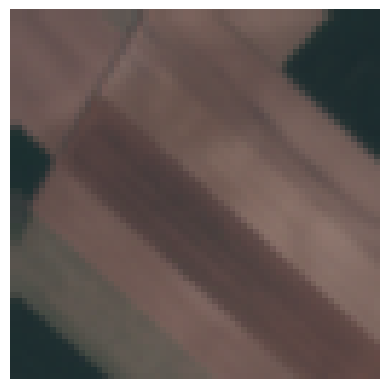

In [571]:
print(f"Predicted: {labels_alphabetic[predicted_label]}")
print(f"Real: {labels_alphabetic[real_label]}")

plt.imshow(rgb.numpy())
plt.axis('off')
plt.show()

In [509]:
def get_model_output(task:ClassificationTask, batch:dict) -> out:
    """
    Returns model outputs given a batch.

    """
    norm_batch = datamodule.aug.augs.Normalize_0(batch["image"])
    
    model = task.model
    model.eval()

    with torch.no_grad():
        out = model(norm_batch)
    return out

def plot_grid_predictions(batch:dict, task:ClassificationTask, labels_dict:dict, n:int=64):
    """
    Modified version with more debugging
    """
    outputs = get_model_output(task, batch)
 
    images = batch["image"][1:n]
    real_labels = batch["label"][1:n]
    N = images.shape[0]
    
    # Determine grid layout
    rows = int(math.sqrt(N))
    cols = math.ceil(N / rows)
    
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2))
    
    # Flatten axes array
    if N > 1:
        axes = axes.flatten()
    else:
        axes = [axes]
    
    for i in range(N):
        ax = axes[i]
        img = images[i]
        
        # Normalize the image
        img = (img - img.min()) / (img.max() - img.min())
        
        # Extract RGB channels
        rgb = img[[3, 2, 1], :, :].permute(1, 2, 0).cpu().numpy()
        
        # Get predictions and actual labels
        logits = outputs[i]
        predicted_idx = logits.argmax().item()
        real_idx = real_labels[i].item()

        # Plot image
        ax.imshow(rgb)
        ax.axis('off')
        ax.set_title(f"Real: {labels_dict.get(real_idx, 'unknown')}", fontsize=8, pad=5)
        ax.text(0.5, -0.1, 
                f"Pred: {labels_dict.get(predicted_idx, 'unknown')}",
                transform=ax.transAxes,
                ha='center', 
                fontsize=8)
    
    # Hide unused subplots
    for j in range(N, len(axes)):
        axes[j].axis('off')
    
    plt.tight_layout()
    plt.show()

In [543]:
def get_random_batch(datamodule, stage='test', batch_size=32):
    if stage == 'test':
        loader = datamodule.test_dataloader()
    elif stage == 'val':
        loader = datamodule.val_dataloader()
    else:
        loader = datamodule.train_dataloader()
    
    # Get the total number of batches in the loader.
    num_batches = len(loader)
    
    # Choose a random batch index.
    random_index = random.randint(0, num_batches - 1)
    
    # Iterate through the loader until we reach the random batch.
    for i, batch in enumerate(loader):
        if i == random_index:
            return batch

## Plotting random test batchs

The problem with our batch approach is that we only get batches from the beginning of the test set, and they're all farmland. Let's take a few random batches and plot them *en masse*.

In [574]:
random_batch = get_random_batch(datamodule, stage='test', batch_size=64)

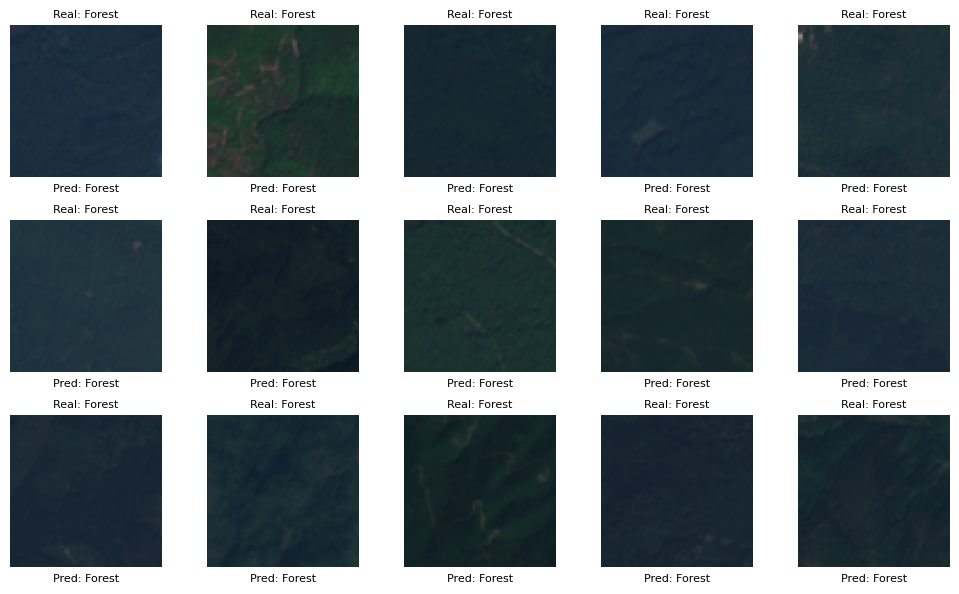

In [576]:
plot_grid_predictions(random_batch, task, labels_alphabetic, n = 16)

In [577]:
random_batch = get_random_batch(datamodule, stage='test', batch_size=64)

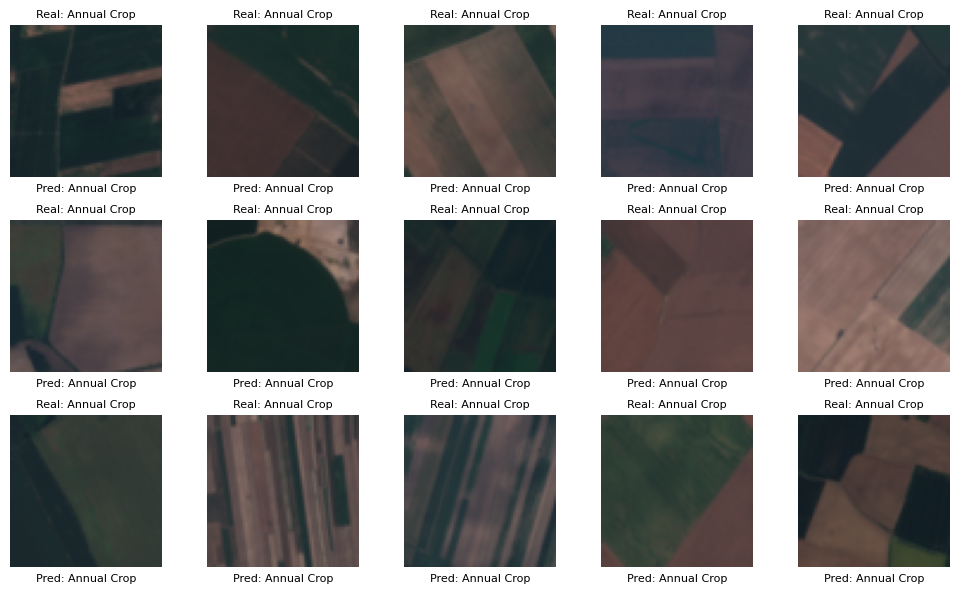

In [578]:
plot_grid_predictions(random_batch, task, labels_alphabetic, n = 16)

In [579]:
random_batch = get_random_batch(datamodule, stage='test', batch_size=64)

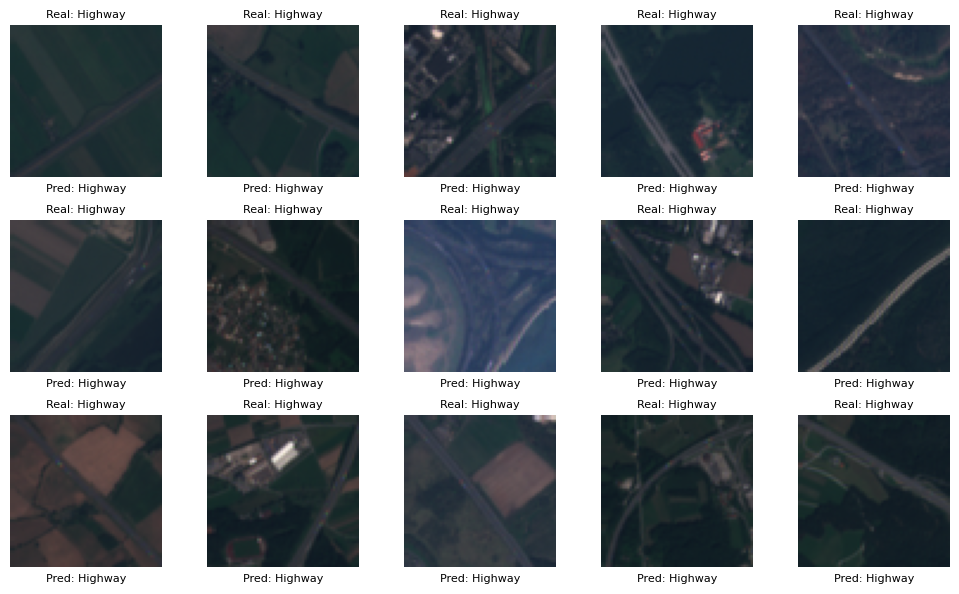

In [580]:
plot_grid_predictions(random_batch, task, labels_alphabetic, n = 16)

# [Part 2C] Case: Predicting on new data

## Predicting on new data

These are good predictions! But we're still stuck in the sandbox of the EuroSAT data. What if we had our own data and we wanted to run the model on it? 

Let's use PyStac from last week to get a Sentinel-2 image from above Montreal and test our model on some patches from it.

In [212]:
import numpy as np
import pystac_client

from IPython.display import Image
from odc.stac import stac_load
from utils import *

In [408]:
sentinel_client = pystac_client.Client.open(
    "https://earth-search.aws.element84.com/v1")

bbox = [-73.98324, 45.38145, -73.41676, 45.71805 ]  
datetime = "2024-07-17/2024-07-30"  # Date range
cloud_cover = 10  # Max cloud cover (%)

Found 1 matching Sentinel-2 images.


In [581]:
# Search for Sentinel-2 L2A imagery.
# It's atmospherically corrected for surfance reflectance only.
search = sentinel_client.search(
    collections=["sentinel-2-l2a"],
    bbox=bbox,
    datetime=datetime,
    query={"eo:cloud_cover": {"lt": cloud_cover}},
    max_items=5,  # Adjust to get more images
)

In [582]:
items = search.item_collection()
print(f"Found {len(items)} matching Sentinel-2 images.")

Found 1 matching Sentinel-2 images.


In [409]:
list(items)[0]

<Item id=S2B_18TWR_20240723_0_L2A>

We filter for the image with the least cloud cover.

In [410]:
min_cloud = get_item_with_min_attribute(items, attr='eo:cloud_cover')
min_cloud.properties['datetime']

'2024-07-23T16:00:38.626000Z'

In [412]:
Image(url=min_cloud.assets["thumbnail"].href, width=400)

This image is very large and we want to focues on Montreal (right edge of the image). We use `shapely` and our `bbox` to filter for that part of the image.

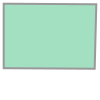

In [413]:
min_cloud_poly = Polygon(*min_cloud.geometry['coordinates'])
min_cloud_poly

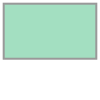

In [414]:
bbox_poly = box(*bbox)
bbox_poly

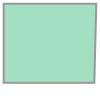

In [415]:
intersection_poly = shapely.intersection(
    bbox_poly,
    min_cloud_poly)

intersection_poly

We then make sure that we get the bands in the data in the same order as the EuroSAT bands. Note that band `B10` is missing from the API endpoint we are using to access Sentinel-2. We will have to address this later.

In [585]:
print(EuroSAT.BAND_SETS['all'])

('B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B09', 'B10', 'B11', 'B12', 'B8A')


In [586]:
bands = ["coastal", "blue", "green", "red", "rededge1",
        "rededge2", "rededge3", "nir", "nir09", 
         "swir16", "swir22", "nir08"]

Now we can load the data using `stac_load`. We make sure to only get the area from within the `bounds` of our `intersection_poly` and at a projection appropriate for Montreal.

In [587]:
sentinel_data = stac_load([min_cloud], 
                    bands = bands,
                    bbox=intersection_poly.bounds,
                    crs="EPSG:32618",
                    chunks={},
                    #resolution=0.5, #could be as low as 0.00009009
                    progress=tqdm).isel(time=0)

What we get is and `xarray.Dataset`.

In [589]:
sentinel_data

<xarray.Dataset> Size: 285MB
Dimensions:      (y: 3787, x: 3133)
Coordinates:
  * y            (y) float64 30kB 5.064e+06 5.064e+06 ... 5.026e+06 5.026e+06
  * x            (x) float64 25kB 5.791e+05 5.791e+05 ... 6.104e+05 6.104e+05
    spatial_ref  int32 4B 32618
    time         datetime64[ns] 8B 2024-07-23T16:00:38.626000
Data variables:
    coastal      (y, x) uint16 24MB dask.array<chunksize=(3787, 3133), meta=np.ndarray>
    blue         (y, x) uint16 24MB dask.array<chunksize=(3787, 3133), meta=np.ndarray>
    green        (y, x) uint16 24MB dask.array<chunksize=(3787, 3133), meta=np.ndarray>
    red          (y, x) uint16 24MB dask.array<chunksize=(3787, 3133), meta=np.ndarray>
    rededge1     (y, x) uint16 24MB dask.array<chunksize=(3787, 3133), meta=np.ndarray>
    rededge2     (y, x) uint16 24MB dask.array<chunksize=(3787, 3133), meta=np.ndarray>
    rededge3     (y, x) uint16 24MB dask.array<chunksize=(3787, 3133), meta=np.ndarray>
    nir          (y, x) uint16 24MB dask.array<chunksize=(3787, 3133), meta=np.ndarray>
    nir09        (y, x) uint16 24MB dask.array<chunksize=(3787, 3133), meta=np.ndarray>
    swir16       (y, x) uint16 24MB dask.array<chunksize=(3787, 3133), meta=np.ndarray>
    swir22       (y, x) uint16 24MB dask.array<chunksize=(3787, 3133), meta=np.ndarray>
    nir08        (y, x) uint16 24MB dask.array<chunksize=(3787, 3133), meta=np.ndarray>

We need to convert it to an `array` in order to use it with our model.

In [431]:
sentinel_np = sentinel_data.compute().to_array().values

In [432]:
sentinel_np.shape

(12, 3787, 3133)

In [590]:
def random_patch(img, patch_size=64):
    """
    Extract a random patch of size patch_size x patch_size 
    from a multi-band image with shape (bands, height, width).
    """
    channels, height, width = img.shape
    y = np.random.randint(0, height - patch_size + 1)
    x = np.random.randint(0, width - patch_size + 1)
    return img[:, y:y+patch_size, x:x+patch_size]

Now we can extract a random patch from this `numpy.array()`. I've written the helper function `random_patch` for this purpose.

In [601]:
patch = random_patch(sentinel_np, patch_size=64)
print("Random patch shape:", patch.shape)

Random patch shape: (12, 64, 64)


We prepare to plot...

In [602]:
# Extract red, green, and blue bands
red = patch[3]    # red band
green = patch[2]  # green band
blue = patch[1]   # blue band

# Stack them to create an RGB image of shape (64, 64, 3)
rgb_patch = np.stack([red, green, blue], axis=-1)

# Set correct data type and normalize
rgb_patch = rgb_patch.astype(np.float32)
rgb_patch /= np.max(rgb_patch)

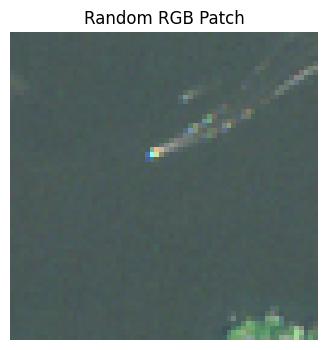

In [603]:
# Plot the RGB patch
plt.figure(figsize=(4, 4))
plt.imshow(rgb_patch)
plt.title("Random RGB Patch")
plt.axis("off")
plt.show()

To actually predict, we need to jump through a few more hoops. First, we have to convert our numpy data to a `torch.tensor()`.

In [604]:
patch = patch.astype(np.float32)
patch = torch.from_numpy(patch)

Then, we have to deal with the missing band, `B10`. I deal with it by inserting random noise into this band. Another way would be to just omit it at the beginning, before we train our model.

In [605]:
# Create random noise.
noise = torch.rand(1, patch.shape[1], patch.shape[2], dtype=patch.dtype)

# Insert the noise channel at index 9.
patch_with_noise = torch.cat((patch[:9], noise, patch[9:]), dim=0)

Now we can get our prediction. A few things to note. Earlier, I wrapped this in the helper function. Let's not do that now. What we do:

1. We normalize according to the `.aug.augs.Normalize_0` function in our data module. This is necessary to make our input compatible with the model.
2. We get the model from `task.model`
3. We disable layers that are irrelevant or harmful when evaluating by setting `model.eval()` (e.g. dropout)
4. We ensure that the model knows we're not training it by setting `torch.no_grad()`. This restricts us to the forward pass, without backpropagation.
5. We get our output

In [606]:
norm_patch = datamodule.aug.augs.Normalize_0(patch_with_noise)

model = task.model
model.eval()

with torch.no_grad():
    out = model(norm_patch)

This time there's no "real label", but this prediction looks quite good most of the time.

In [609]:
predicted_label = out.argmax().item()

In [ ]:
print(f"Predicted: {labels_alphabetic[predicted_label]}")

# Plot the RGB patch
plt.figure(figsize=(4, 4))
plt.imshow(rgb_patch)
plt.title("Random RGB Patch")
plt.axis("off")
plt.show()

# [Part 2D] Hands on: Predicting on new data

**Prompt:** This is a straightforward exercise. Go back to the beginning of part 2C. Pick a new area that's of personal interest to you and replicate the analysis in that part. To get started you need to decide at least on the following:

- What is the `bbox`?
- What is the `datetime` range?
- Do you want to use the same cloud cover threshold?